Krishang Bose

# Pre-requirements & Definitions

Environment Setup Installation (can be escaped)

In [57]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Imports

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import json

from scipy import stats
from scipy.stats import uniform, randint, norm
import shap

from tqdm import tqdm
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, RandomizedSearchCV

import warnings # removing sns style warnings
warnings.filterwarnings('ignore', category=FutureWarning)

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score, f1_score, log_loss, confusion_matrix
import xgboost as xgb
from sklearn.decomposition import PCA
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import SVC

## Constants

In [59]:
# CONSTANTS
ID = 'id'
LABEL = 'diagnosis'
MALIGNANT_VALUE = 'M'
BENIGN_VALUE = 'B'
MALIGNANT_NAME = 'Malignant'
BENIGN_NAME = 'Benign'
PALETTE = 'coolwarm'
SEED = 0
SKIP_MODELS_HYPERPARAMETERS_FINETUNE=True

# Visualization Hyperparameters
TITLE_FONT_SIZE = 12
PLOT_TEXT_SIZE = 11
NUM_COLUMNS = 5

# Label Occurences
FIGURE_SIZE = (6, 4)

# Corr Matrix
CORR_FIGURE_SIZE = (18, 10)
VALUE_FORMATING = ".2f"
CORR_PALETTE = "ch:s=-.2,r=.6"

# Box plots
coolwarm_palette = sns.color_palette("coolwarm", n_colors=2)
BOX_PALETTE = {BENIGN_VALUE: coolwarm_palette[0], MALIGNANT_VALUE: coolwarm_palette[-1]}
WHISKER_LEN = 2.
BOX_PLOT_FIGURE_SIZE = (15, 5)

# KDE
WIDTH_PER_SUBPLOT = HEIGHT_PER_SUBPLOT = 5
LOG_SCALED = False
BENIGN_COLOR = 'blue'
MALIGNANT_COLOR = 'red'

# Outliers DIST
COLOR = 'skyblue'
ALPHA = 0.6

# Training
TEST_PORTION = 0.1
METRIC_FP_PRECISION = 3
XGBOOST_MODEL_OBJECTIVE = 'binary:logistic'
METRIC_CRITERIA = 'recall'
SECOND_METRIC_CRITERIA = 'f1'
NUM_KFOLD = 10
NUM_ITER = 10 # Default
CLASSIFER_THRESHOLD = 0.5

## Metrics Definition

In [60]:
metrics_dict = {
    'logloss': lambda labels, preds: log_loss(labels, preds),
    'accuracy': lambda labels, preds: accuracy_score(labels, preds),
    'precision': lambda labels, preds: precision_score(labels, preds, zero_division=1),
    'recall': lambda labels, preds: recall_score(labels, preds, zero_division=1),
    'f1': lambda labels, preds: f1_score(labels, preds, zero_division=1),
}

## Loading dataset

In [61]:
file_path = 'data/breast-cancer.csv'
df = pd.read_csv(file_path)

# Dataset Analysis

The Breast Cancer Dataset contains measurements derived from breast cancer x-rays.   
Each entry includes features such as the radius, texture, and area of tumor cells, which are taken from multiple observations or parts of the tumor.  

Therefore, every feature is an aggregation of statistical parameters such as mean, standard error, and maximum (often referred to as "worst").

## Data Structure

dataset columns

In [62]:
df_dtypes = pd.DataFrame(df.dtypes).reset_index()
df_dtypes.columns = ['Column', 'Data Type']
print(df_dtypes)

                     Column Data Type
0                        id     int64
1                 diagnosis       str
2               radius_mean   float64
3              texture_mean   float64
4            perimeter_mean   float64
5                 area_mean   float64
6           smoothness_mean   float64
7          compactness_mean   float64
8            concavity_mean   float64
9       concave points_mean   float64
10            symmetry_mean   float64
11   fractal_dimension_mean   float64
12                radius_se   float64
13               texture_se   float64
14             perimeter_se   float64
15                  area_se   float64
16            smoothness_se   float64
17           compactness_se   float64
18             concavity_se   float64
19        concave points_se   float64
20              symmetry_se   float64
21     fractal_dimension_se   float64
22             radius_worst   float64
23            texture_worst   float64
24          perimeter_worst   float64
25          

Our data consists of numeric measurements [floating-point numbers]

In [63]:
non_numeric_cols = [ID, LABEL]
numerical_df = df.drop(non_numeric_cols, axis=1)

In [64]:
f"Number of Samples: {numerical_df.shape[0]}"

'Number of Samples: 569'

## Data Distribution Description

In [65]:
numerical_df.describe().drop('count', axis=0).T

,mean,std,min,25%,50%,75%,max
radius_mean,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave points_mean,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


#### Observations


---


1. Data range variability, like in `area_worst` (185.2 to 4254.0) and `area_mean` (143.5 to 2501.0), suggests potential outliers and the need for normalization.

2. Outliers: Significant difference between the Q3 and max value (or min value and Q1) suggest outliers' existence.  
Examples:
  - `concavity_worst` Q3=0.38, max=1.25
  - `area_worst` Q3=1084.0, max=4254.0
  - `area_se` Q3=45.2, max=542.2
  - `perimeter_se` Q3=3.35, max=21.98
  - `area_mean` Q3=782.7, max=2501.0


---


Alignment with Related Works & Datasets:  
Actual Dataset source: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic  

Upon reviewing related works, the distribution appears reliable and originates from the source dataset. However, it's unclear whether the skewed values are due to measurement errors.


## Quantitative Measure of Skewness

In [66]:
skewness_rate_df = numerical_df.skew().sort_values(ascending=False)
skewness_rate_df

area_se                    5.447186
concavity_se               5.110463
fractal_dimension_se       3.923969
perimeter_se               3.443615
radius_se                  3.088612
smoothness_se              2.314450
symmetry_se                2.195133
compactness_se             1.902221
area_worst                 1.859373
fractal_dimension_worst    1.662579
texture_se                 1.646444
area_mean                  1.645732
compactness_worst          1.473555
concave points_se          1.444678
symmetry_worst             1.433928
concavity_mean             1.401180
fractal_dimension_mean     1.304489
compactness_mean           1.190123
concave points_mean        1.171180
concavity_worst            1.150237
perimeter_worst            1.128164
radius_worst               1.103115
perimeter_mean             0.990650
radius_mean                0.942380
symmetry_mean              0.725609
texture_mean               0.650450
texture_worst              0.498321
concave points_worst       0

All features are right-skewed in different scales, especially standard error measurements. Further Outliers & Skewness investigation is needed.

## Data Quality and Nullness

In [67]:
numerical_df.isnull().sum()

radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

Based on the null counts provided for the dataset, it can be concluded that there are no missing values across all features listed.

# Prediction Problem Definition

### The objective

Predicting the diagnosis of breast tissues as either malignant (M) or benign (B). This task involves utilizing a comprehensive set of diagnostic measurements.

### The Criteria metric - Recall

It is crucial to accurately identify as many true positives as possible to ensure that individuals with cancer receive the necessary treatment.   Concurrently, maintaining a high true negative rate is important to prevent misdiagnosing healthy individuals, thereby safeguarding them from receiving unnecessary and potentially harmful treatments.

# Data Visualizations

### Label Occurences

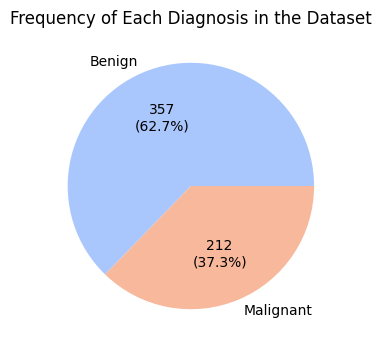

In [68]:
full_names = {MALIGNANT_VALUE: MALIGNANT_NAME, BENIGN_VALUE: BENIGN_NAME}
label_counts = df[LABEL].value_counts().rename(index=full_names)

plt.figure(figsize=FIGURE_SIZE)
plt.pie(label_counts, labels=label_counts.index, autopct=lambda p: '{:.0f}\n({:.1f}%)'.format(p * sum(label_counts) / 100, p), colors=sns.color_palette(PALETTE, len(label_counts)))
plt.title('Frequency of Each Diagnosis in the Dataset', fontsize=TITLE_FONT_SIZE)
plt.show()

 An imbalance between the two classes, with benign cases being more common than malignant.

### Pair-wise Pearson Correlation Heatmap

In [69]:
numerical_df[LABEL] = df[LABEL].apply(lambda y: (float)(y == MALIGNANT_VALUE))

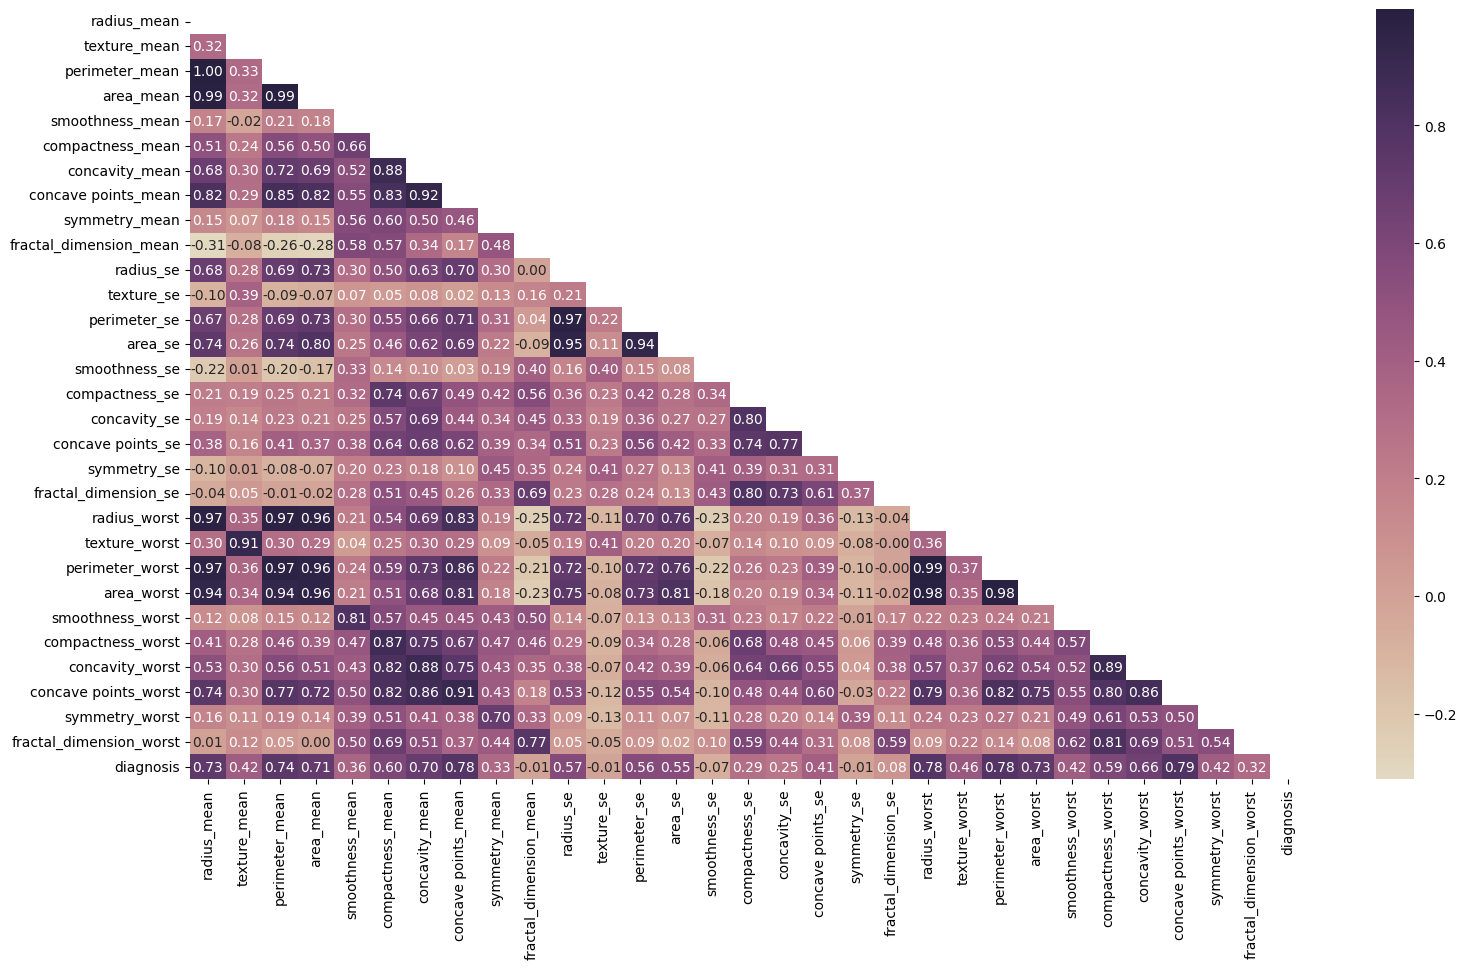

In [70]:
corr = numerical_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=CORR_FIGURE_SIZE)
sns.heatmap(corr, mask=mask, cmap=sns.color_palette(CORR_PALETTE, as_cmap=True), annot=True, fmt=VALUE_FORMATING)
plt.show()


#### Observations


---


1. **Key Predictors**: `radius_mean`, `perimeter_mean`, `area_mean`,
   `concavity_mean`, `concave points_mean`, and `concave points_worst`
   have significant correlations with diagnosis, showing their
   importance for the predictive model.

2. **Redundant Features and Multicollinearity**: Strong correlations
   among size-related features (`radius_mean`, `perimeter_mean`,
   `area_mean`) and shape descriptors (`compactness_mean`,
   `compactness_worst`, `concavity_mean`, `concavity_worst`,
   `concave points_mean`, `concave points_worst`) indicate
   multicollinearity. This suggests these features provide overlapping
   information, making it possible to reduce them to streamline the
   model without compromising its predictive power.

3. **Weak Correlations**: Features like `fractal_dimension_mean` and
   specific `texture_se` and `symmetry_se` metrics exhibit minimal
   correlation with diagnosis, making them potential candidates for
   exclusion to simplify the model and possibly enhance performance.


---



### Identifying Outliers Across TOP10 Skewed Distributions (Boxplot)

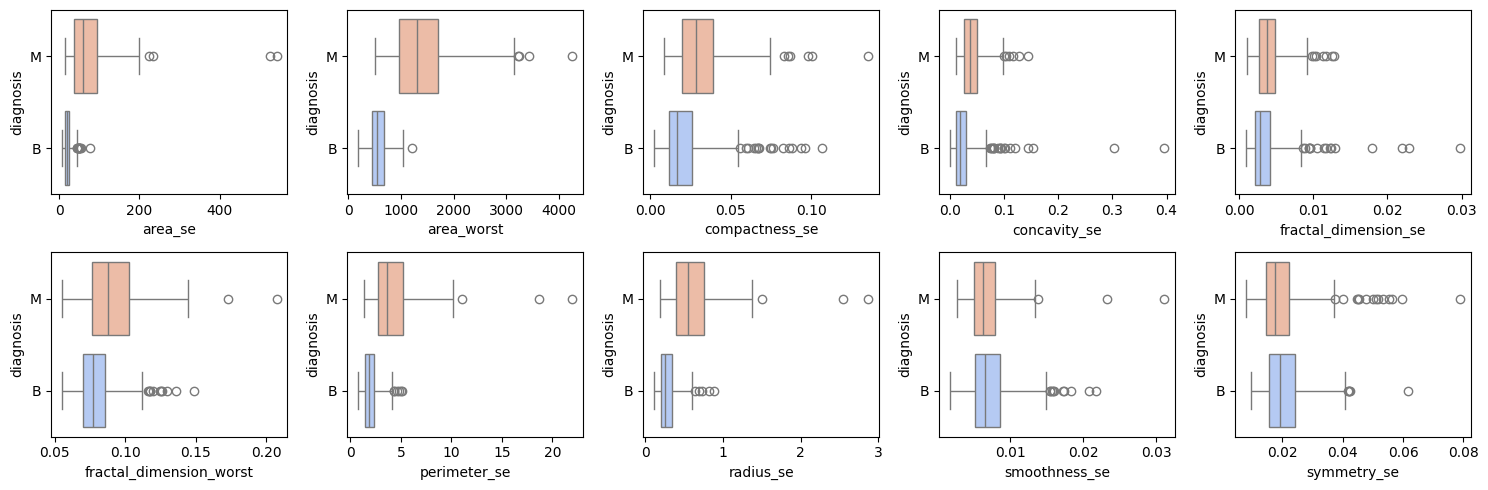

In [71]:
features_lexico_sorted = sorted(numerical_df.drop(LABEL, axis=1).columns)
top_10_skewed_features = skewness_rate_df.nlargest(10).index.tolist()
features_filtered = [feature for feature in features_lexico_sorted if feature in top_10_skewed_features]

num_features = len(features_filtered)
num_rows = num_features // NUM_COLUMNS + (1 if num_features % NUM_COLUMNS > 0 else 0)

# Create a grid of subplots
fig, axes = plt.subplots(num_rows, NUM_COLUMNS, figsize=BOX_PLOT_FIGURE_SIZE)

for i, feature in enumerate(features_filtered):
    row, col = divmod(i, NUM_COLUMNS)
    sns.boxplot(y=LABEL, x=feature, data=df, ax=axes[row, col], whis=WHISKER_LEN, palette=BOX_PALETTE)

# Hide any unused subplots
for j in range(i + 1, num_rows * NUM_COLUMNS):
    axes.flat[j].set_visible(False)

plt.tight_layout()
plt.show()


#### Observations


---


Outliers Reinforcing Distinction

(Area_worst, Perimeter_se, Area_se, Radius_se):  
- Outliers emphasize the existing trend of much higher values in Malignant cases, aiding in the distinction without negatively impacting it.

Outliers Adding Noise

(Fractal_dimension_se, Fractal_dimension_worst, Smoothness_se, Symmetry_se, Compactness_se):  
- Outliers mix with both diagnoses, adding noise and complicating classification.

(Concavity_se):  
- While it generally indicates malignancy with higher values, outliers do not distinctly enhance or weaken the separation between diagnoses, but adds some small effect.


---



#### Hypothesis: Same Outlier Data Points

Due to the high correlation (collinearity) among many skewed features, it is highly likely that outliers in one feature are also outliers in another correlated feature. For instance, it makes sense for `Area_se` and `Area_worst` to share outliers, as a large area might also result in significant size variability (standard error) across different measurements.

### Comparative Kernel Density Estimation: Top 5 & Bottom 5 Correlated Features for Benign vs. Malignant

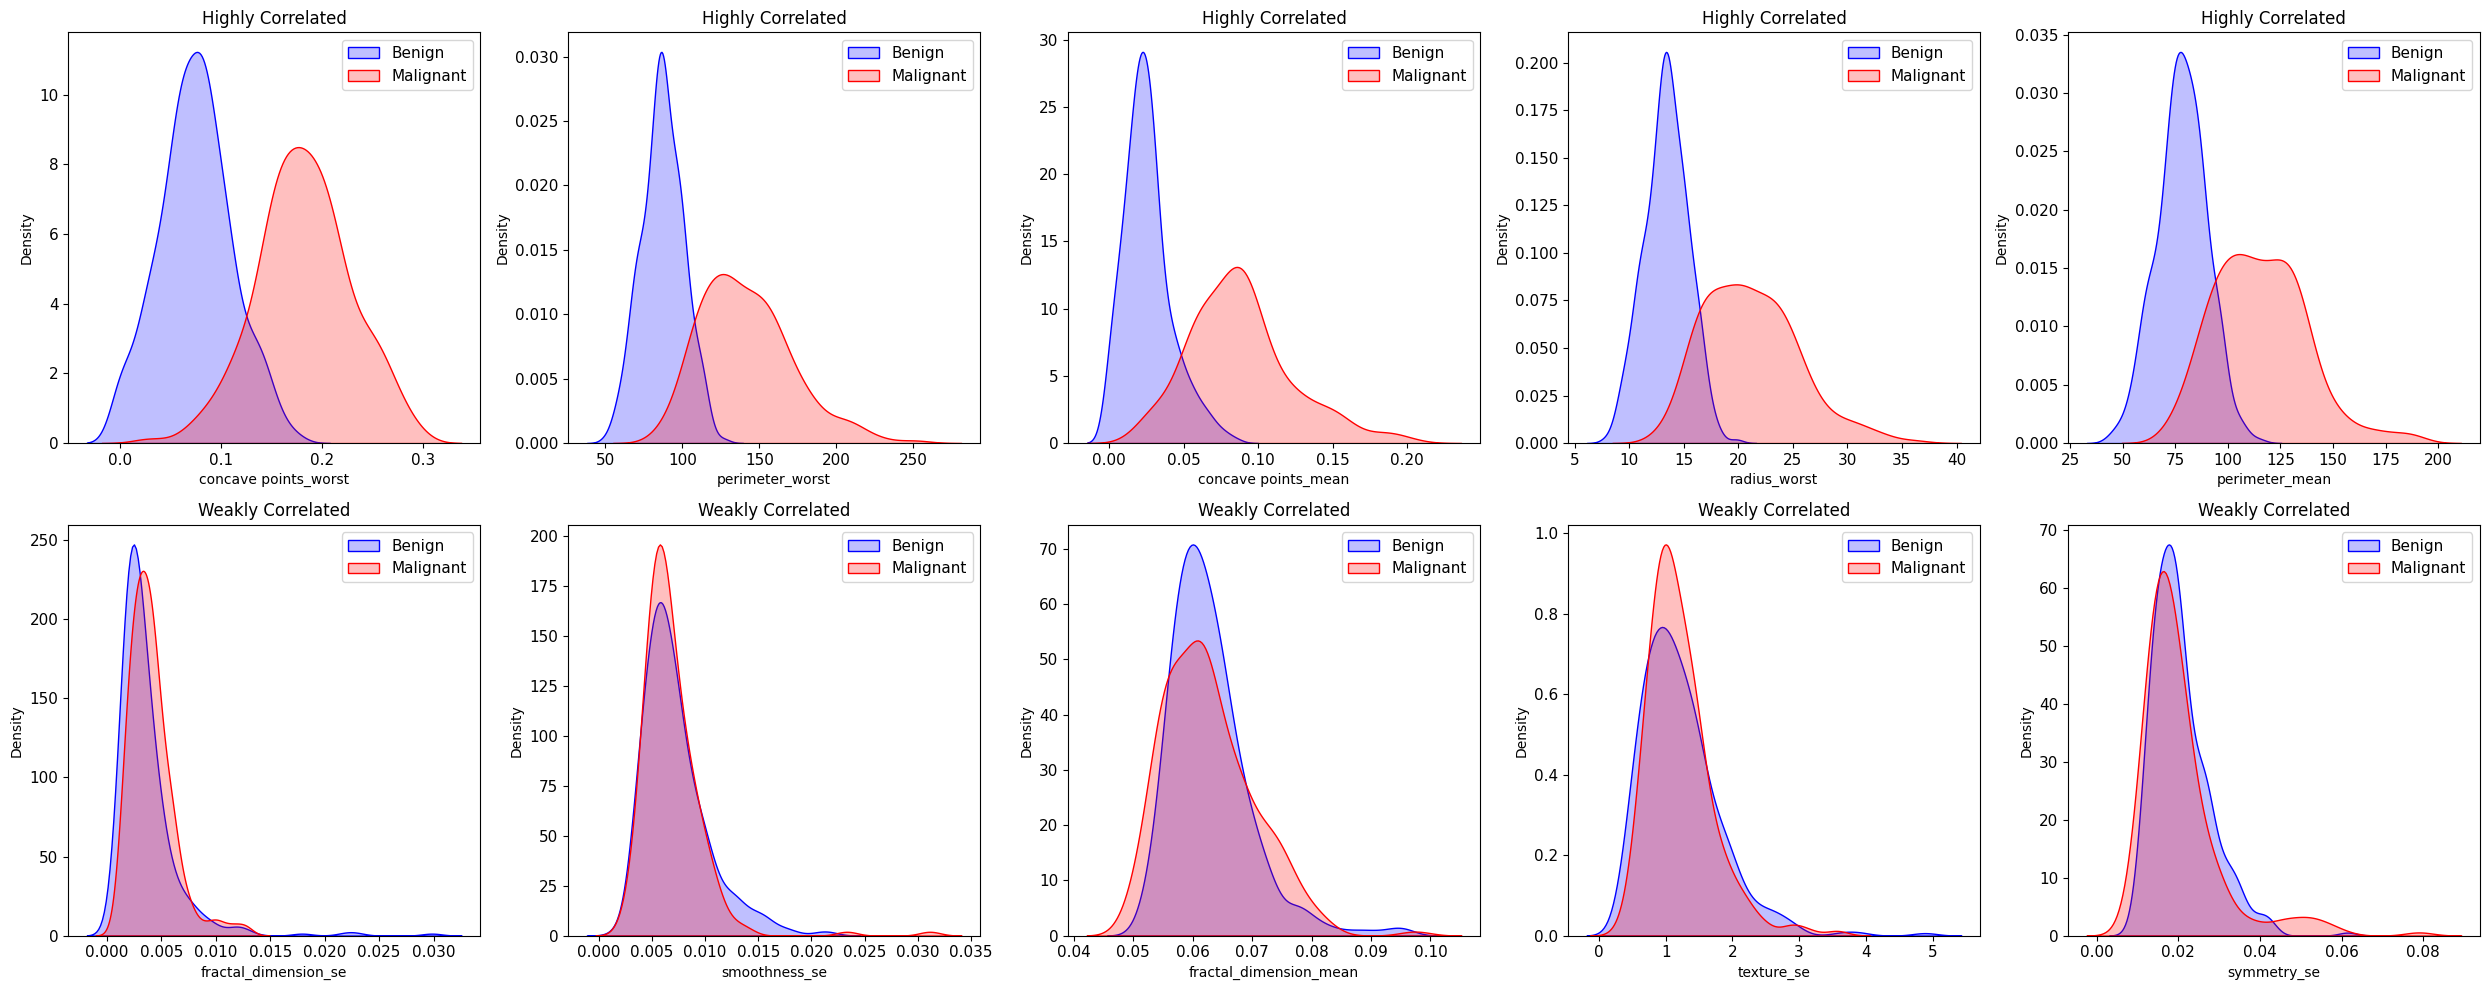

In [72]:
correlations = corr[LABEL].drop(LABEL).abs().sort_values(ascending=False)
top_features = correlations.head(NUM_COLUMNS).index.tolist() + correlations.tail(NUM_COLUMNS).index.tolist()

num_rows = (len(top_features) // NUM_COLUMNS + (1 if len(top_features) % NUM_COLUMNS else 0))
fig, axes = plt.subplots(num_rows, NUM_COLUMNS, figsize=(WIDTH_PER_SUBPLOT * NUM_COLUMNS, HEIGHT_PER_SUBPLOT * num_rows), squeeze=False)

for index, feature in enumerate(top_features):
    ax = axes[index // NUM_COLUMNS, index % NUM_COLUMNS]
    sns.kdeplot(numerical_df[df[LABEL] == BENIGN_VALUE][feature], ax=ax, label=BENIGN_NAME, shade=True, color=BENIGN_COLOR, log_scale=LOG_SCALED)
    sns.kdeplot(numerical_df[df[LABEL] == MALIGNANT_VALUE][feature], ax=ax, label=MALIGNANT_NAME, shade=True, color=MALIGNANT_COLOR, log_scale=LOG_SCALED)
    ax.set_title(f'{"Highly" if index < NUM_COLUMNS else "Weakly"} Correlated', fontsize=TITLE_FONT_SIZE)
    ax.legend(fontsize=PLOT_TEXT_SIZE)
    ax.tick_params(axis='both', labelsize=PLOT_TEXT_SIZE)

for ax in axes.flat[index + 1:]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

#### Observations


---


Correlation & KDE Overlapping:  
- Features with smaller overlaps between the benign and malignant KDE distributions generally show a stronger correlation with the diagnosis, and vice versa.

Highly Correlated Features:  
- The separation between benign and malignant distributions in `concave points_worst/mean`, `perimeter_worst/mean` and `radius_worst` features indicates these are strong predictors of malignancy.

Weakly Correlated Features:  
- Overlapping densities in `fractal dimension_se/mean`, `smoothness_se`, `texture_se`, and `symmetry_se` metrics suggest they have low discriminatory power.  
- Removing features with the most overlapping distributions, such as `fractal_dimension_se`, can reduce noise and simplify the model.
- We can see that most of the weakly has strong right tail, log transform can considered.


---



### Collecting & Visualizing the Distribution of Outliers in the Dataset
Our goal is to identify outlier data points (with `id`)  from previous visualizations. Given the high correlation among features, it is highly likely that some data points are outliers across multiple features. Understanding this distribution is key to determining our approach to managing outliers.

### Collecting Outliers using configured Whishker and IQR

In [73]:
outliers_mask = pd.DataFrame(False, index=df[ID], columns=features_lexico_sorted)


def mark_outliers_by_diagnosis_with_id(df, features, whis=2.0):
    # Function to calculate and mark outliers using IQR, preserving sample IDs
    for diagnosis in df[LABEL].unique():
        diagnosis_group = df[df[LABEL] == diagnosis]
        for feature in features:
            Q1 = diagnosis_group[feature].quantile(0.25)
            Q3 = diagnosis_group[feature].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - whis * IQR
            upper_bound = Q3 + whis * IQR

            # Mark outliers in the mask DataFrame, using id col to reference the correct samples
            outliers_indices = diagnosis_group[(diagnosis_group[feature] < lower_bound) | (diagnosis_group[feature] > upper_bound)][ID]
            outliers_mask.loc[outliers_indices, feature] = True

mark_outliers_by_diagnosis_with_id(df, features_lexico_sorted, WHISKER_LEN)
outliers_samples = outliers_mask[outliers_mask.any(axis=1)]
outliers_samples = outliers_samples.reset_index()

### Visualizing Outliers

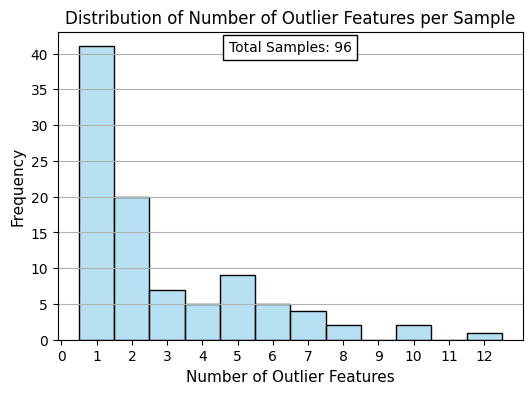

In [74]:
outlier_counts = outliers_samples.drop(columns=[ID]).sum(axis=1)
plt.figure(figsize=FIGURE_SIZE)

bins = np.arange(outlier_counts.min(), outlier_counts.max() + 2) - 0.5
sns.histplot(outlier_counts, bins=bins, stat='count', color=COLOR, alpha=ALPHA)

total_samples = len(outlier_counts)
plt.text(0.5, 0.95, f'Total Samples: {total_samples}', ha='center', va='center',
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white'))

plt.title('Distribution of Number of Outlier Features per Sample', fontsize=TITLE_FONT_SIZE)
plt.xlabel('Number of Outlier Features', fontsize=PLOT_TEXT_SIZE)
plt.ylabel('Frequency', fontsize=PLOT_TEXT_SIZE)
plt.xticks(range(int(outlier_counts.max()) + 1))
plt.grid(axis='y')
plt.show()

#### Observations


---


Outlier Feature Frequency:  
- The majority of samples exhibit a low number of outliered features.

Implications for Model Robustness:  
- Considerable number of data points has multiple outlier features, it can weaken the reliability of a model. We can evaluate different strategies for handling outliers for these data points.

---



# Model Training - XGBoost

shifting from EDA to XGBoost classifier training with 10-fold cross-validation.

### Data Preparation

In [75]:
def data_preparation(training_df, labels, test_size=TEST_PORTION, random_state=SEED):
    X = training_df if isinstance(training_df, np.ndarray) else training_df.values
    encoder = LabelEncoder()
    y = encoder.fit_transform(labels)
    X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=test_size, random_state=random_state)

    return X_train, X_test, Y_train, Y_test

In [76]:
X_train_with_id, X_test_with_id, Y_train, Y_test = data_preparation(df.drop([LABEL], axis=1), df[LABEL])

# Removing id values
X_train = X_train_with_id[:, 1:]
X_test = X_test_with_id[:, 1:]

training_columns = df.columns.drop([ID, LABEL]).to_list()

## Training

### Set XGBoost parameters

In [77]:
def init_xgboost_params(objective, seed, n_splits):
    params = {'objective': objective, 'seed': seed}
    # StratifiedKFold keeps class ratio balanced in each fold
    kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return params, kf

In [78]:
params, kf = init_xgboost_params(XGBOOST_MODEL_OBJECTIVE, SEED, NUM_KFOLD)

### XGBoost Evaluation Callback Function

XGBoost only provides average metrics across all folds during cross-validation, hiding specific fold trends like overfitting. Our Callback Function evaluates custom metrics per fold to uncover these trends.


In [79]:
def eval_metrics(preds, data, metrics_dict, threshold):
    labels = data.get_label()
    preds_binary = (preds > threshold).astype(int)
    metrics_results = []
    for metric_name, func in metrics_dict.items():
        if metric_name != 'logloss':  # XGBoost handles this internally
            metrics_results.append((metric_name, func(labels, preds_binary)))
    return metrics_results

### Training Loop
This loop facilitates the training and evaluation of 10 XGBoost models through K-Fold cross-validation:

1. Splitting the data per fold into train and validation sets.
2. Converting data into DMatrix format for optimal training efficiency.
3. Training the model with both data sets and employing custom metrics for evaluation.
4. Adding each trained model to a collection for subsequent analysis.
5. Evaluating each model on a test set to update the metrics summary and determine the best model based on predefined criteria.


In [80]:
def training_loop(X_train, Y_train, params, eval_metrics, kf, metrics_dict, num_iter=NUM_ITER, verbose_eval=False, threshold=CLASSIFER_THRESHOLD):
    def custom_metric(preds, data):
        return eval_metrics(preds, data, metrics_dict=metrics_dict, threshold=threshold)
    best_model = None
    best_evals_result = {}
    best_metrics = {k: float('-inf') for k in metrics_dict.keys()}  # Initialize best metrics

    # Start KFold loop
    for train_index, val_index in kf.split(X_train, Y_train):
        # Split the dataset for the current fold
        x_train, x_val = X_train[train_index], X_train[val_index]
        y_train, y_val = Y_train[train_index], Y_train[val_index]

        # Convert into DMatrix
        dtrain = xgb.DMatrix(x_train, label=y_train)
        dval = xgb.DMatrix(x_val, label=y_val)

        # Train the model
        evals_result = {}
        model = xgb.train(params, dtrain, num_iter, [(dtrain, 'train'), (dval, 'val')],
                          custom_metric=custom_metric, evals_result=evals_result, verbose_eval=verbose_eval)

        # Determine if current fold's validation metric is the best
        criteria_value = metrics_dict[METRIC_CRITERIA](y_val, (model.predict(dval) > threshold).astype(int))

        # Update best model if current fold's validation performance is superior
        if criteria_value > best_metrics[METRIC_CRITERIA]:
            best_metrics[METRIC_CRITERIA] = criteria_value
            best_model = model
            best_evals_result = evals_result

    return best_model, best_evals_result

In [81]:
best_model, best_evals_result = training_loop(X_train, Y_train, params, eval_metrics, kf, metrics_dict)

## Evaluation Metrics and Results

### Plotting Training & Validation Metrics for Best-Fold

Ploting a series of graphs for training and validation metrics over epochs for the best performing fold

#### Parameters:
- evals_results: Contains 'train' and 'val' keys with metric names and epoch values.
- metrics: List of metric names to plot (e.g., 'accuracy', 'loss').


In [82]:
def plot_metrics_row(evals_results, metrics_names, figsize=(20, 3), lw=2):
    fig, axes = plt.subplots(1, len(metrics_dict), figsize=figsize)
    for ax, metric_name in zip(axes, metrics_names):
        epochs = len(evals_results['train'][metric_name])
        x_axis = range(0, epochs)
        ax.plot(x_axis, evals_results['train'][metric_name], label=f'{metric_name}_train', color='blue', lw=lw)
        ax.plot(x_axis, evals_results['val'][metric_name], label=f'{metric_name}_val', color='orange', lw=lw)
        ax.set_title(f'Best Fold - {metric_name}')
        ax.set_ylabel(metric_name)
        ax.set_xlabel('Epoch')
        ax.legend()

    plt.tight_layout()
    plt.show()

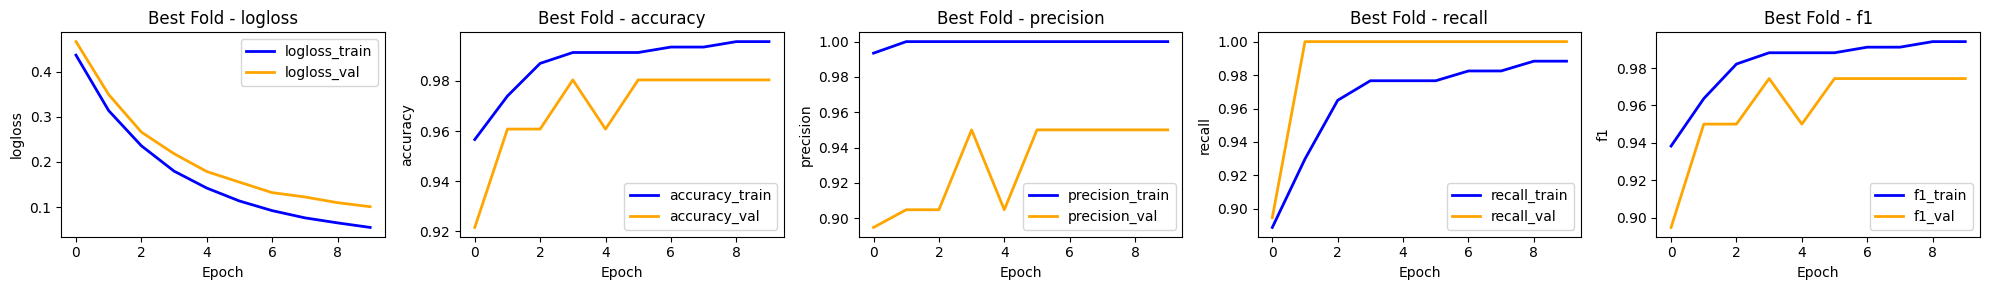

In [83]:
plot_metrics_row(best_evals_result, metrics_dict.keys())

#### Observations

---

**Recall (The Criteria):**  
- Recall converges well with training, indicating a good fit and progress in reducing false negatives. An increase in epochs may be beneficial as the graph shows potential for further improvement after 10 epochs.

**Log Loss:**  
- The converging trends between training and validation indicate a well-fitted model.

**Precision:**  
- The precision graph indicates a considerable number of false positives within the chosen fold, which is acceptable given our focus on maximizing recall to minimize false negatives.

---

Overall, the trends suggest that the model is converging appropriately and could benefit from additional epochs.


### Summary of best fold performance

Summarizing the results over the test split: average and standard deviation of cross-validation results, both mean and standard deviation from all folds, and from the best one.

In [84]:
def visualize_test_results(metrics_dict, X_test, Y_test, best_model, threshold=CLASSIFER_THRESHOLD):
    rows = []

    # Iterate through each specified metric to calculate results
    for metric, func in metrics_dict.items():
        if metric == 'logloss':
            # predict_proba for sklearn models; xgb.Booster.predict() already returns probabilities
            if hasattr(best_model, 'predict_proba'):
                preds_proba = best_model.predict_proba(X_test)[:, 1]
            else:
                preds_proba = best_model.predict(X_test)
            value = func(Y_test, preds_proba)
        else:
            # For other metrics, calculate directly
            value = func(Y_test, (best_model.predict(X_test) > threshold).astype(int))
        rounded_value = round(value, METRIC_FP_PRECISION)
        rows.append([metric, rounded_value])

    df_metrics = pd.DataFrame(rows, columns=['Metric', 'Best_Fold_on_Test'])
    return df_metrics

baseline_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(X_test), Y_test, best_model, CLASSIFER_THRESHOLD)
baseline_metrics

,Metric,Best_Fold_on_Test
0,logloss,0.107
1,accuracy,0.982
2,precision,0.957
3,recall,1.000
4,f1,0.978


# Feature Engineering

In [85]:
def compare_models(dfs, names, postfix='_Best_Fold'):
    modified_dfs = []

    for df, name in zip(dfs, names):
        renamed_df = df.rename(columns={"Best_Fold_on_Test": f"{name}{postfix}"})
        modified_dfs.append(renamed_df)

    comparison_df = modified_dfs[0]
    for mod_df in modified_dfs[1:]:
        comparison_df = pd.merge(comparison_df, mod_df, on='Metric')

    return comparison_df

### Standardization (Z-score)

In [86]:
scaler = StandardScaler()
scaler.fit(X_train)

# Apply the transformation to both train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

best_model, best_evals_result = training_loop(X_train_scaled, Y_train, params, eval_metrics, kf, metrics_dict)
oversampled_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(X_test_scaled), Y_test, best_model)
standartization_comparison_df = compare_models([baseline_metrics, oversampled_metrics], ['Baseline', 'Standartization'])
display(standartization_comparison_df)

,Metric,Baseline_Best_Fold,Standartization_Best_Fold
0,logloss,0.107,0.107
1,accuracy,0.982,0.982
2,precision,0.957,0.957
3,recall,1.000,1.000
4,f1,0.978,0.978


feature standartization in order to prevent dominance of certain features during model training.  
[It's less important for XGBoost, as it is less sensitive to feature scales, but it might be helpful if we use regularization techniques]

## Positive Class Over Sampling

In [87]:
oversampler = RandomOverSampler(random_state=SEED)
OS_X_train_balanced, OS_Y_train_balanced = oversampler.fit_resample(X_train, Y_train)
best_model, best_evals_result = training_loop(OS_X_train_balanced, OS_Y_train_balanced, params, eval_metrics, kf, metrics_dict)
oversampled_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(X_test), Y_test, best_model)
oversampled_comparison_df = compare_models([baseline_metrics, oversampled_metrics], ['Baseline', 'OverSampling'])
display(oversampled_comparison_df)

,Metric,Baseline_Best_Fold,OverSampling_Best_Fold
0,logloss,0.107,0.123
1,accuracy,0.982,0.930
2,precision,0.957,0.875
3,recall,1.000,0.955
4,f1,0.978,0.913


As mentioned earlier, our dataset is heavily imbalanced, like many medical datasets. Oversampling the positive instances (cancer samples) is not effective in that case.

## Feature Selection

In [88]:
DIAGNOSIS_CORR_THRESHOLD = 0.25
corr_with_diagnosis = corr['diagnosis']
low_corr_features = corr_with_diagnosis[abs(corr_with_diagnosis) < DIAGNOSIS_CORR_THRESHOLD].index.tolist()
print("Dropped features with absolute correlation value less than", DIAGNOSIS_CORR_THRESHOLD, ":", low_corr_features)

Dropped features with absolute correlation value less than 0.25 : ['fractal_dimension_mean', 'texture_se', 'smoothness_se', 'symmetry_se', 'fractal_dimension_se']


In [89]:
# Get column indices to drop
drop_indices = [training_columns.index(feature) for feature in low_corr_features]

# Apply feature selection on the existing splits
FS_X_train = np.delete(X_train, drop_indices, axis=1)
FS_X_test = np.delete(X_test, drop_indices, axis=1)

best_model, best_evals_result = training_loop(FS_X_train, Y_train, params, eval_metrics, kf, metrics_dict)
fs_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(FS_X_test), Y_test, best_model)

In [90]:
fs_comparison_df = compare_models([baseline_metrics, fs_metrics], ['Baseline', 'Feature_Selection'])
display(fs_comparison_df)

,Metric,Baseline_Best_Fold,Feature_Selection_Best_Fold
0,logloss,0.107,0.106
1,accuracy,0.982,0.982
2,precision,0.957,0.957
3,recall,1.000,1.000
4,f1,0.978,0.978


Feature selection based on exploratory data analysis (EDA) seems to significantly improve our baseline model. Although XGBoost inherently performs feature selection during its training process by identifying the most informative features, it's likely that the default configuration wasn't ideal for this dataset.

## Feature Extraction (Dimentionality Reduction) - PCA

In [91]:
# PCA transformation
pca = PCA(n_components=15)
PCA_X_train = pca.fit_transform(X_train)
PCA_X_test = pca.transform(X_test)

# Training with PCA-transformed data
best_model, best_evals_result = training_loop(PCA_X_train, Y_train, params, eval_metrics, kf, metrics_dict)
pca_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(PCA_X_test), Y_test, best_model)

In [92]:
pca_comparison_df = compare_models([baseline_metrics, pca_metrics], ['Baseline', 'PCA'])
display(pca_comparison_df)

,Metric,Baseline_Best_Fold,PCA_Best_Fold
0,logloss,0.107,0.158
1,accuracy,0.982,0.930
2,precision,0.957,0.909
3,recall,1.000,0.909
4,f1,0.978,0.909


As previously discussed, our dataset has multiple correlated features, indicating multicollinearity. Some features have low correlation, and selecting just a few from each subgroup could lead to information loss. A better approach might be using PCA, which creates fewer, orthogonal features from linear combinations of the original ones. This approach offers:

- Noise Reduction
- Lower Data Complexity
- Independent Features

And indeed, it looks effective.

## Hard-Outliers Removal

In [93]:
NUM_OF_OUTLIER_FEATURES_THRESHOLD = 6

# Identify outliers in 'outliers_samples' ('id' is in first col)
outlier_count = outliers_samples.drop(columns=['id']).sum(axis=1)
filtered_samples = outliers_samples[outlier_count > NUM_OF_OUTLIER_FEATURES_THRESHOLD]
indices_to_remove = filtered_samples['id'].values

# Apply the removal on the training set only
train_mask = ~np.isin(X_train_with_id[:, 0], indices_to_remove)  # Mask for non-outliers
test_mask = ~np.isin(X_test_with_id[:, 0], indices_to_remove)

# Filter samples with corresponding id
OR_X_train = X_train_with_id[train_mask][:, 1:]
OR_Y_train = Y_train[train_mask]

OR_X_test = X_test_with_id[test_mask][:, 1:]
OR_Y_test = Y_test[test_mask]

print(f"{len(indices_to_remove)} outliers have been removed from the training set.")

best_model, best_evals_result = training_loop(OR_X_train, OR_Y_train, params, eval_metrics, kf, metrics_dict)
outliers_metrics = visualize_test_results(metrics_dict, xgb.DMatrix(OR_X_test), OR_Y_test, best_model)

9 outliers have been removed from the training set.


In [94]:
outliers_comparison_df = compare_models([baseline_metrics, outliers_metrics], ['Baseline', 'Outliers_Removal'])
display(outliers_comparison_df)

,Metric,Baseline_Best_Fold,Outliers_Removal_Best_Fold
0,logloss,0.107,0.122
1,accuracy,0.982,0.947
2,precision,0.957,0.913
3,recall,1.000,0.955
4,f1,0.978,0.933


The outliers in our dataset represent extreme data points across multiple features (as shown in the histogram above).

Though not ideal, we can remove these data points and label them as abnormal, as they might not be representative of typical data.

To decide which points to remove, we set a threshold based on the number of outlier features in each data point. This "hard-outliers" removal has significantly improved our model's performance.

However, this should be a last resort, as we aim to work with all data.  
We've explained above that we couldn't found consistent criteria for abnormal data.

## Summary

For our baseline model, with default configuration:

| Method                         | Improvement                |
|-------------------------------|----------------------------|
| Positive Class Oversampling   | No Effect                   |
| Principal Component Analysis (PCA) | Minor                 |
| Feature Selection              | Significant                |
| Outlier Removal                 | Significant                |
| Scaling                          | No Effect                   |


To improve our best model from HyperParameter fine-tuning, we will combine the top feature engineering methods and test each individually to assess their unique impact on model performance.

In [95]:
# Feature selection + Hard-Outliers Removal Splits
FS_OR_X_train = np.delete(OR_X_train, drop_indices, axis=1)
FS_OR_X_test = np.delete(OR_X_test, drop_indices, axis=1)

# Alternative ML Models Training

We will explore 3 alternatives for our baseline model, combining hyperparameter tuning.

- XGBoost [but with hyperparameter tuning]
- Random Forest
- Support Vector Machine


## XGBoost

   
* **Motivation**: To evaluate if a baseline model's performance can be improved through parameter configuration search compared to default settings.  

* **Configuration** idea: Employ a RandomizedSearchCV with varied distributions for key hyperparameters, including learning rate, estimators, depth, child weight, gamma, and subsample rate, using cross-validation to identify the best-performing XGBoost configuration.



### Parameters Configuration

In [96]:
xgboost_conf = {
    'model': XGBClassifier(random_state=SEED),
    'param_dict': {
        'learning_rate': uniform(0.001, 0.3),
        'n_estimators': randint(100, 1000),
        'max_depth': randint(1, 10),
        'min_child_weight': norm(3, 1),
        'gamma': uniform(0, 0.3),
        'subsample': uniform(0.7, 0.3),
    },
    'random_result': None
}

## Random Forest

* **Motivation**: Random Forest is robust, leveraging an ensemble of decision trees to provide stability and resilience against overfitting.

* **Configuration idea**: Utilize RandomizedSearchCV with varied distributions for key hyperparameters in Random Forest, such as the number of estimators, maximum features, depth, samples required for split and leaf, and whether to bootstrap. Use cross-validation to find the optimal configuration for improved accuracy and robustness.  


### Parameters Configuration

In [97]:
rf_conf = {
    'model': RandomForestClassifier(random_state=SEED),
    'param_dict': {
        'n_estimators': randint(100, 500),
        'max_features': ['log2'],
        'max_depth': randint(1, 6),
        'min_samples_split': randint(2, 10),
        'min_samples_leaf': randint(1, 5),
        'bootstrap': [True, False]
    },
    'random_result': None
}

## SVM

* **Motivation**: SVM is known for its robustness and effectiveness in high-dimensional spaces like ours [30+ features]

* **Configuration idea**: Apply RandomizedSearchCV with varied distributions to optimize SVM's hyperparameters, including C, kernel, \
degree, gamma, coef0, shrinking, and tolerance. Utilize cross-validation to identify the optimal SVM configuration for better \
accuracy and generalization.  


### Parameters Configuration

In [98]:
svm_conf = {
    'model': SVC(probability=True),  # probability=True needed for log_loss
    'param_dict': {
        'C': uniform(0.01, 10),
        'kernel': ['linear', 'rbf'],
        'degree': randint(1, 10),
        'gamma': ['scale', 'auto'],
        'coef0': uniform(0, 10),
        'shrinking': [True, False],
        'tol': uniform(1e-5, 1e-1),
    },
    'random_result': None
}

## Perform Grid Search For on all of the models (SVM, XGBoost, Random Forest)

Combine Configurations

In [99]:
gs_conf = {
    'SVM': svm_conf,
    'XGBoost': xgboost_conf,
    'RF': rf_conf
}

### SKIP BLOCK

In [100]:
base_dir = "skip_files"

csv_path = os.path.join(base_dir, "models_comparison.csv")
models_comparison_df = pd.read_csv(csv_path)

json_path = os.path.join(base_dir, "best_configurations.json")
with open(json_path, 'r') as json_file:
    best_configurations_data = json.load(json_file)

best_configurations = best_configurations_data["best_configurations"]
best_cv_model = best_configurations_data["best_cv_model"]

Run Hyper-Parameter fine-tuning for all the models

In [101]:
if not SKIP_MODELS_HYPERPARAMETERS_FINETUNE:
  # Run hyperparameters finetuning for our chosen models
  metrics_results = [baseline_metrics]
  best_configurations = {name: None for name in gs_conf.keys()}
  cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

  for m_name, m_conf in tqdm(gs_conf.items(), total=len(gs_conf), desc='Training models'):
      random_search = RandomizedSearchCV(estimator=m_conf['model'], param_distributions=m_conf['param_dict'], scoring=METRIC_CRITERIA, cv=cv, n_iter=10, random_state=SEED, n_jobs=-1)

      m_conf['random_result'] = random_search.fit(X_train, Y_train)
      best_configurations[m_name] = m_conf['random_result'].best_params_

      # pred on test set using the model with the best parameters
      best_model = random_search.best_estimator_
      metrics_results.append(visualize_test_results(metrics_dict, X_test, Y_test, best_model))

  # compare to baseline model
  models_comparison_df = compare_models(metrics_results, ['Baseline'] + [f'GridSearch_{m_name}' for m_name in gs_conf])
  print(f'\nbest models configurations were: {best_configurations}')
else:
  print(f'\n{best_cv_model} best given configuration was: {best_configurations[best_cv_model]}')
display(models_comparison_df)


XGBoost best given configuration was: {'gamma': 0.22758468729670714, 'learning_rate': 0.03277228215633764, 'max_depth': 8, 'min_child_weight': 2.1459042606982752, 'n_estimators': 775, 'subsample': 0.7558997029980279}


,Metric,Baseline_Best_Fold,GridSearch_SVM_Best_Fold,GridSearch_XGBoost_Best_Fold,GridSearch_RF_Best_Fold
0,logloss,0.124,1.265,0.632,2.529
1,accuracy,0.930,0.965,0.982,0.930
2,precision,0.875,0.917,0.957,0.875
3,recall,0.955,1.000,1.000,0.955
4,f1,0.913,0.957,0.978,0.913


Based on the following results, the XGBoost model with specified cross-validation performs the best compared to our baseline, SVM, and Random Forest models. With this optimal configuration identified, we'll use it along with effective feature engineering to enhance the model's performance.

# Optimal Model and Feature Engineering Combinations

In [102]:
datasets = {
    'Baseline Data': (X_train, Y_train, X_test, Y_test),
    'PCA': (PCA_X_train, Y_train, PCA_X_test, Y_test),
    'Hard-Outliers Removal': (OR_X_train, OR_Y_train, OR_X_test, OR_Y_test),
    'Positive Class Over Sampling': (OS_X_train_balanced, OS_Y_train_balanced, X_test, Y_test),
    'Feature Selection': (FS_X_train, Y_train, FS_X_test, Y_test),
    'Feature Selection + Outliers Removal': (FS_OR_X_train, OR_Y_train, FS_OR_X_test, OR_Y_test)
}

xgboost_conf = {
    'model': XGBClassifier(random_state=SEED),
    'param_dict': best_configurations['XGBoost']
}

metrics_results = []
model_dict = {}
for dataset_name, (_X_train, _Y_train, _X_test, _Y_test) in tqdm(datasets.items(), total=len(datasets), desc='Training chosen model over datasets'):

    # Initialize model with the given configuration
    xgboost_model = XGBClassifier(
        random_state=xgboost_conf['model'].random_state,
        **xgboost_conf['param_dict']
    )

    # Train the model over all dataset
    xgboost_model.fit(_X_train, _Y_train)

    model_dict[dataset_name] = xgboost_model

    # Visualize test results
    metrics_results.append(visualize_test_results(metrics_dict, _X_test, _Y_test, xgboost_model))

combination_comparison_df = compare_models(metrics_results, datasets.keys(), postfix='')
display(combination_comparison_df)

Training chosen model over datasets:   0%|          | 0/6 [00:00<?, ?it/s]

Training chosen model over datasets: 100%|██████████| 6/6 [00:06<00:00,  1.10s/it]


,Metric,Baseline Data,PCA,Hard-Outliers Removal,Positive Class Over Sampling,Feature Selection,Feature Selection + Outliers Removal
0,logloss,0.057,0.124,0.073,0.053,0.046,0.061
1,accuracy,0.982,0.947,0.947,0.965,0.982,0.965
2,precision,0.957,0.913,0.880,0.955,0.957,0.917
3,recall,1.000,0.955,1.000,0.955,1.000,1.000
4,f1,0.978,0.933,0.936,0.955,0.978,0.957


#### Observations


---


Based on our comprehensive evaluation of different models

1. **Baseline**
2. **XGBoost + Cross-Validation (CV)**
3. **SVM + Cross-Validation (CV)**
4. **RandomForest + Cross-Validation (CV)**

The best combination to maximize Recall (1st criterion) and F1 (2nd criterion) scores is **"XGBoost + CV"** trained on the Baseline/Manual Feature Selection dataset. It's worth to mention that, as we anticipated, with the right configuration, XGBoost can automatically select features.


---

# Error and Model Performance Analysis

## Wrong Predictions

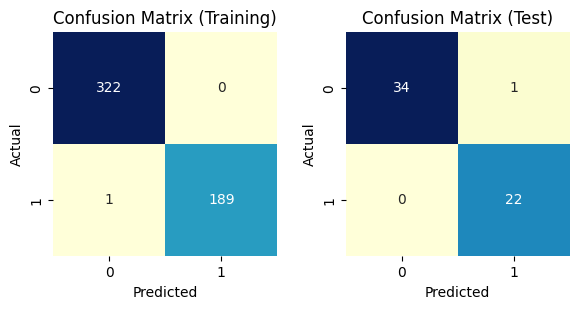

In [103]:
dataset_name = "Feature Selection"
_X_train, _Y_train, _X_test, _Y_test = datasets[dataset_name]
model = model_dict[dataset_name]

def plot_confusion_matrix(predictions, ground_truth, set_type, cmap='coolwarm', annot_size=12):
    cm = confusion_matrix(ground_truth, predictions)
    ax = sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, square=True, cbar=False, annot_kws={"size": annot_size})
    ax.set_title(f"Confusion Matrix ({set_type})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.figure(figsize=(6, 3))

train_predictions = model.predict(_X_train)
test_predictions = model.predict(_X_test)

plt.subplot(1, 2, 1)
plot_confusion_matrix(train_predictions, _Y_train, "Training", cmap='YlGnBu', annot_size=10)

plt.subplot(1, 2, 2)
plot_confusion_matrix(test_predictions, _Y_test, "Test", cmap='YlGnBu', annot_size=10)

plt.tight_layout()
plt.show()

It seems we've captured most of the small dataset. It's important to note that the dataset is small, and the test set wasn't seen during training.

Lets take a look at the missed samples.

Train Misses:

In [104]:
train_predictions = model.predict(_X_train)
incorrect_train_predictions_idx = train_predictions != _Y_train
incorrect_train_predictions_samples = pd.DataFrame(_X_train[incorrect_train_predictions_idx], columns=df.columns.drop([ID, LABEL] + low_corr_features))
display(incorrect_train_predictions_samples)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,11.76,18.14,75.0,431.1,0.09968,0.05914,0.02685,0.03515,0.1619,0.645,...,13.36,23.39,85.1,553.6,0.1137,0.07974,0.0612,0.0716,0.1978,0.06915


Test Misses:

In [105]:
test_predictions = model.predict(_X_test)
incorrect_test_predictions_idx = test_predictions != _Y_test
incorrect_test_predictions_samples = pd.DataFrame(_X_test[incorrect_test_predictions_idx], columns=df.columns.drop([ID, LABEL] + low_corr_features))
display(incorrect_test_predictions_samples)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,radius_se,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,14.64,15.24,95.77,651.9,0.1132,0.1339,0.09966,0.07064,0.2116,0.5115,...,16.34,18.24,109.4,803.6,0.1277,0.3089,0.2604,0.1397,0.3151,0.08473


Let's take a look at the standardized values.

In [106]:
numerical_description = numerical_df.describe().drop('count', axis=0)
numerical_description = numerical_description.apply(pd.to_numeric, errors='coerce')
mean_std_description = numerical_description.loc[['mean', 'std']][incorrect_test_predictions_samples.columns]

incorrect_test_predictions_samples_zscore = (incorrect_test_predictions_samples - mean_std_description.loc['mean']) / mean_std_description.loc['std']
considerable_zscore = incorrect_test_predictions_samples_zscore.stack()[abs(incorrect_test_predictions_samples_zscore).stack() > 1]
considerable_zscore

0  smoothness_mean    1.197352
   symmetry_mean      1.110302
   compactness_se     1.040969
   texture_worst     -1.210041
dtype: float64

Look like most of the values are very common, except for these 4 features.

We will revisit it after using explainability tools, which might help us understand why we missed it.

## Explainability

Utilizing SHAP (stands for: SHapley Additive exPlanations) is a method in machine learning that helps us understand how our model works. It breaks down each prediction into parts and tells us which features are most important for that prediction.

### SHAP Summary Plots

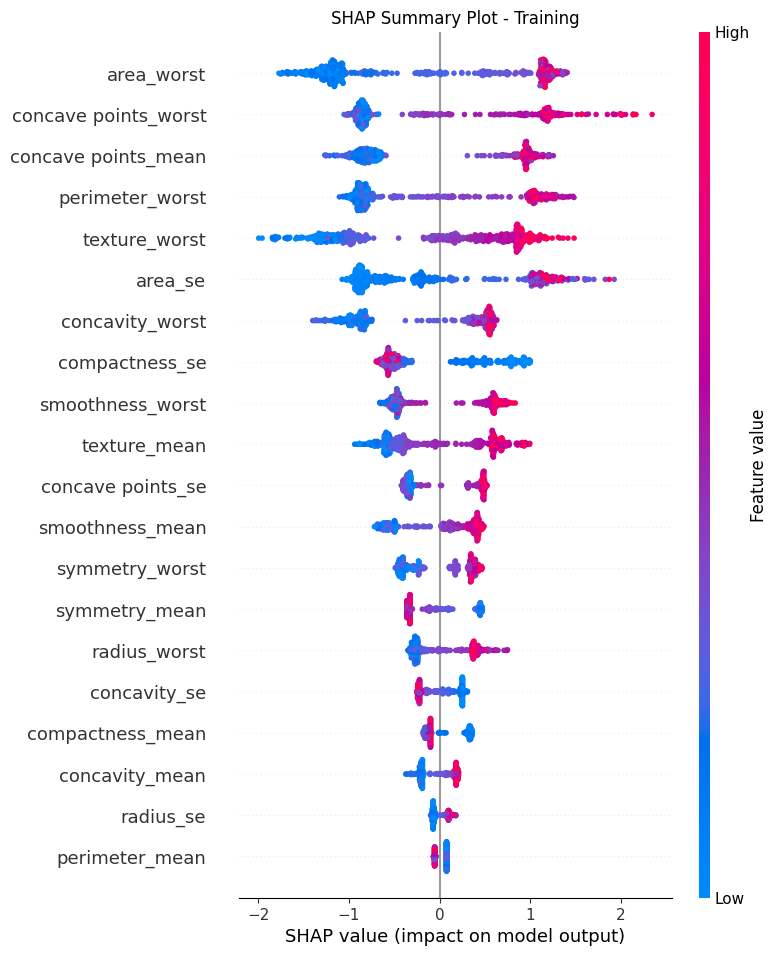

In [107]:
explainer = shap.Explainer(model)

# Restore numpy to df
_X_train_df = pd.DataFrame(_X_train, columns=df.columns.drop([ID, LABEL] + low_corr_features))
_X_test_df = pd.DataFrame(_X_test, columns=df.columns.drop([ID, LABEL] + low_corr_features))

shap_values_train = explainer.shap_values(_X_train_df)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_train, _X_train_df, plot_type='dot', show=False)
plt.title("SHAP Summary Plot - Training")
plt.show()

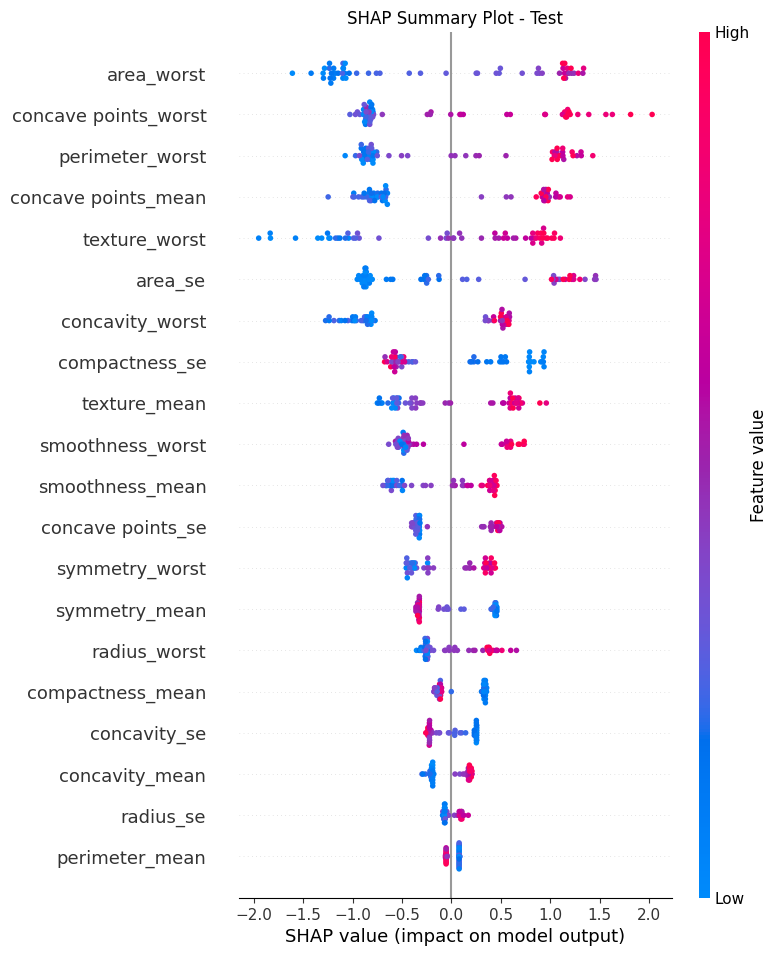

In [108]:
shap_values_test = explainer.shap_values(_X_test_df)

plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values_test, _X_test_df, plot_type='dot', show=False)
plt.title("SHAP Summary Plot - Test")
plt.show()

This SHAP summary plots indicates the impact of various features on the model's predictions. It uses a dot plot to show SHAP values for individual samples, with colors representing the feature's value (blue for low, red for high), and the dots' position indicating the impact on the model's output (left for Benign, right for Malignant).

#### Observations
---


1. The most significant features, according to this plot, are those that create a clear separation between red and blue dots. This aligns with our exploratory data analysis (EDA), suggesting that the model has learned the desired distribution of these features.

2. Some features do not provide a strong separation between classes. For instance, `fractal_dimension_worst` shows less distinct division, implying it might be less useful for classification. However, it does seem to contribute to the classification of Malignant data points, so its removal requires careful consideration.

3. Both summaries have similar distributions of SHAP values, indicating that the model's explanations for test predictions align with its explanations for training predictions.


---


### Feature Importance

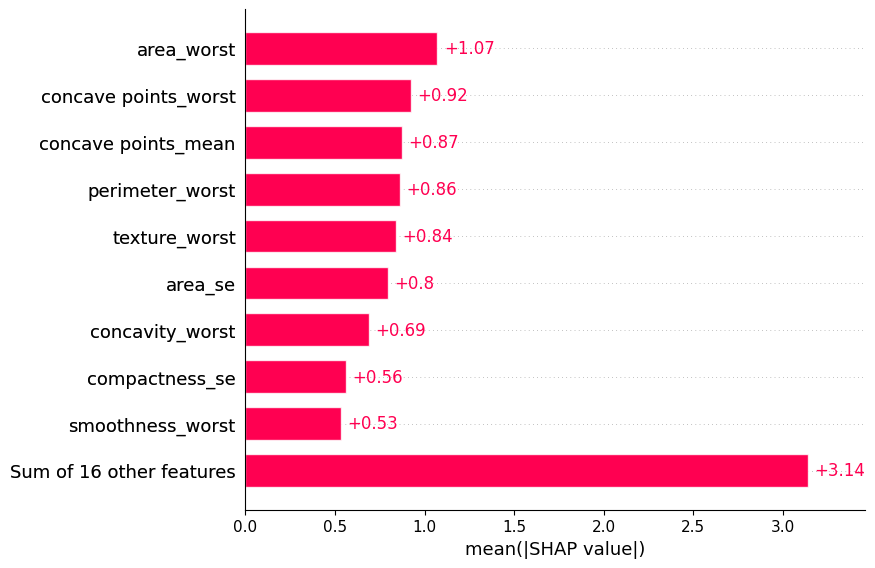

In [109]:
shap.plots.bar(explainer(_X_train_df))

As we already mentioned in Summary Plot's observations, it seems that the most significant features in decision made were indeed the most correlated features.

In [110]:
# Reminder TOP10 Correlated Features
top_features

['concave points_worst',
 'perimeter_worst',
 'concave points_mean',
 'radius_worst',
 'perimeter_mean',
 'fractal_dimension_se',
 'smoothness_se',
 'fractal_dimension_mean',
 'texture_se',
 'symmetry_se']

### Test Wrong Prediction Analysis

In [ ]:
shap.plots.bar(explainer(incorrect_test_predictions_samples))

We can see that `texture_worst` had the most significant impact on incorrect predictions. Based on the training distribution (which we will check to see if it's approximately normal), we will calculate the probability of having the same or a higher value for `texture_worst`.

Using Z-Score Tables:
To find the cumulative probability for a Z-score of -1.210041, you would look for the corresponding value in a standard normal distribution table.

Checking whether `texture_worst` follows an approximately normal distribution, using QQ plot of our training data and normal distribution

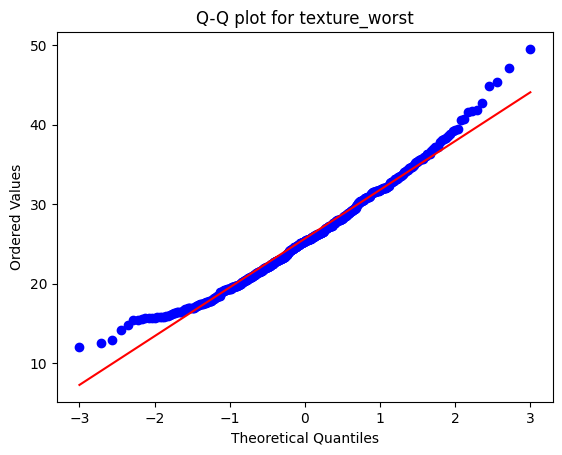

In [ ]:
plt.figure()
stats.probplot(pd.DataFrame(_X_train, columns=df.columns.drop([ID, LABEL] + low_corr_features))["texture_worst"], dist="norm", plot=plt)
plt.title(f"Q-Q plot for texture_worst")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Ordered Values")
plt.show()

We can see that the data doesn't follow a normal distribution (we already knew that many features are skewed), so we won't attempt to approximate the probability of a Z-score of -1.21. Overall, this value for `texture_worst` seems to have a significant impact on the prediction, and it appears to be less common compared to the other 24 features.

Possible Solution:

Consider adding more data with similar values [which we currently don't have] into the training splits.
This might change many of our assumptions and potentially improve model performance, focusing less on uncommon values of medium-correlated features.

# Summary

We chose to work with the [Wisconsin Breast Cancer Dataset](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic), which aims to distinguish between malignant and benign tumors using 30 numerical features and a given ground truth (gt).

As we analyzed the data, we noticed that some of these 30 features were crucially highly correlated with the target variable.

We divided the dataset into two splits:
* Training
* Test

The test split was kept unobserved by the model to mimic real-world scenarios.

We used several visualization and analysis methods in our pipeline, such as:

* Target Distribution (Pie Chart) – Revealed an imbalance between classes.
* Pearson Correlation – Identified less correlated features.
* Skewness Analysis using Box and KDE Plots – Revealed distinct patterns in feature distributions.
* Outlier Distribution Analysis – Identified hard-outlier data points.

Based on these analyses, we employed the following feature engineering techniques:

* Oversampling
* Feature Selection
* Hard-Outliers Removal
* Principal Component Analysis

We also trained an XGBoost model with default configuration, achieving fairly good results, though recall wasn't ideal—false-negative predictions in a medical context can have severe consequences.

We trained three selected models, now with hyperparameter fine-tuning:
* Support Vector Machine
* Random Forest
* XGBoost

After training and applying feature engineering, we found that the manual feature selection combined with XGBoost provided similar predictions compared to the default XGBoost model on the test split. This was noteworthy because XGBoost has built-in feature selection capabilities, suggesting our manual selection and analysis were quite effective.

Continuing our analysis, we explored:
1. False predictions and their underlying causes.
2. Feature importance in these incorrect predictions.
3. SHAP summary plots for both test and training data to identify and compare key differences.
4. Potential solutions for false predictions, possibly through acquiring more data.
5. Feature importance across the training split.

Overall, this medical dataset, sourced from a well-known global hospital, turned out to be less complex than anticipated, Unfortunately, we couldn't find additional data samples or extensions for this dataset.
It was intriguing to explore and apply the concepts learned in class.


# References

## Academic Papers
These papers utilize the Wisconsin Breast Cancer Dataset in their studies:

- [Paper 1](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC9398810/)
- [Paper 2](https://www.mdpi.com/2673-7426/3/3/42)

## Official Dataset Repository
The original source for the dataset:

- [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic)

## Code Notebooks from Kaggle
Here are some notable Kaggle notebooks that explore the Wisconsin Breast Cancer Dataset:

- [Notebook 1](https://www.kaggle.com/code/youdayyy/breast-cancer-classification-xgb-96)
- [Notebook 2](https://www.kaggle.com/code/devendrasingh22/logistic-regression)
- [Notebook 3](https://www.kaggle.com/code/shaikhabdulrafay03/perceptron-using-gradient-descent)

## Important Notes
- Our approach focuses on real-world scenarios, emphasizing higher recall to minimize the risk of misdiagnosis and the potential negative consequences for patients.
- We did not rely on any existing Kaggle notebooks for our analysis.
- We explored additional research sources to better understand valid values for our sample distributions.
- Most Kaggle notebooks do not conduct thorough error analysis or extensive Exploratory Data Analysis (EDA) as we did.
